In [ ]:
# 캐글 데이터 다운로드
!mkdir -p ~/.kaggle
%cd /content/drive/MyDrive/
!chmod 600 kaggle.json
!cp kaggle.json ~/.kaggle
%cd /content
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split

In [17]:
# 검증을 위한 매트릭스 함수

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print("정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}".format(accuracy, precision, recall, f1, roc_auc))

In [11]:
card_df = pd.read_csv('creditcard.csv')
card_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
card_df.Class.value_counts()

0    284315
1       492
Name: Class, dtype: int64

해당 데이터의 레이블은 매우 불균형하다. 이렇게 불균형이 심할 경우 예측 성능의 문제가 생길 수 있다. 적은 레이블을 가진 데이터에 대해서는 충분히 학습하지 못하고 다수의 레이블의 데이터에 치우쳐진 학습을 하게 된다.

지도학습에서는 이런 문제를 해결하기 위해서 적절한 학습 데이터를 확보하는 방법으로 **오버 샘플링과 언더 샘플링**이 있다. 일반적으로 **오버 샘플링** 방식이 성능상 유리하기 때문에 주로 사용된다. 

- 언더 샘플링 : 많은 데이터 셋을 적은 데이터 셋 수준으로 감소 시킨다. 너무 많은 데이터를 감소시키기 때문에 일반적으로 잘 사용하지 않는다. 

- 오버 샘플링 : 적은 데이터 셋을 증식시켜 학습을 위한 충분한 데이터를 확보하는 방법이다. 단순히 증식만 시키면 과적합되기 때문에 피쳐를 약간씩 변형하면서 증식한다. 대표적으로 **SMOTE**방식이 있다. 

    **SMOTE**는 적은 데이터 셋에 있는 데이터들의 K 최근접 이웃을 찾아서 이 데이터와 K개 이웃들의 차이를 일정 값으로 만들어서 기존 데이터와 약간 차이나는 새로운 데이터들을 생성하는 방법이다.

# 데이터 일차 가공 및 모델 학습/예측/평가 (baseline model)

In [54]:
# 필요없는 Time 컬럼 드롭하기
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)
    return df_copy

# X와 y를 분리하고 훈련/테스트 셋 분리
def get_train_test_dataset(df=None):
    df_copy = get_preprocessed_df(df)
    X_features = df_copy.iloc[:, :-1]
    y_target = df_copy.iloc[:, -1]
    X_train, X_test, y_train, y_test = \
    train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [16]:
# 훈련/테스트 셋 레이블 분포 확인
print(y_train.value_counts()/y_train.shape, '\n\n', y_test.value_counts()/y_test.shape)

0    0.998275
1    0.001725
Name: Class, dtype: float64 

 0    0.998268
1    0.001732
Name: Class, dtype: float64


훈련/테스트 셋 모두 같은 비율로 레이블이 나눠진 것을 확인할 수 있다. 

In [55]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, lr_pred, lr_pred_proba)

오차 행렬
[[85281    14]
 [   56    92]]
정확도: 0.9992, 정밀도: 0.8679, 재현율: 0.6216, F1: 0.7244, AUC: 0.9609


In [19]:
# 모델과 데이터를 받아서 학습/예측/평가하는 함수 정의
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    get_clf_eval(tgt_test, pred, pred_proba)

In [23]:
# lgbm
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(n_estimatiors=1000, num_leaves=64, n_jobs=1, boost_from_average=False)    
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test) 

오차 행렬
[[85290     5]
 [   38   110]]
정확도: 0.9995, 정밀도: 0.9565, 재현율: 0.7432, F1: 0.8365, AUC: 0.9779


- boost_from_average=False 

`오차 행렬
[[85290     5]
 [   38   110]]
정확도: 0.9995, 정밀도: 0.9565, 재현율: 0.7432, F1: 0.8365, AUC: 0.9779`
 
- boost_from_average=True (Default)

`오차 행렬
[[85068   227]
 [   72    76]]
정확도: 0.9965, 정밀도: 0.2508, 재현율: 0.5135, F1: 0.3370, AUC: 0.6681`

데이터가 매우 불균형할 경우 `boost_from_average=False` 로 설정해줘야 한다.


# 데이터 분포도 변환 후 모델 학습/예측/평가

## 표준화

먼저 중요 피쳐의 분포도를 살펴본다. 

로지스틱 회귀는 선형 모델인데 대부분의 선형 모델은 중요 피쳐의 값이 정규 분포 형태를 유지하는 것을 선호한다. 

Amout 피쳐는 신용 카드 사용 금액으로 정상/사기 트랜잭션을 결정하는 매우 중요한 속성일 가능성이 높다. Amount 피쳐의 분포도를 확인해본다.


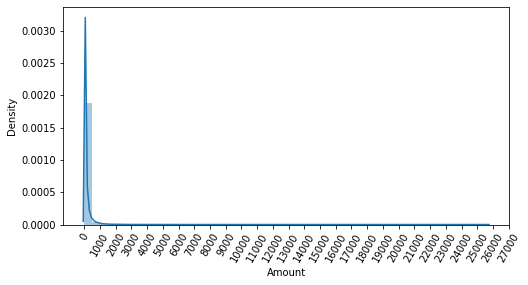

In [26]:
import seaborn as sns
plt.figure(figsize=(8, 4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.distplot(card_df['Amount'])
plt.show()

데이터의 분포가 매우 치우쳐져있는 것을 볼 수 있다. 이를 표준화해서 정규분포 형태로 변환한다.

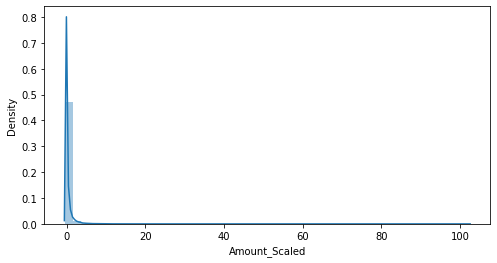

In [42]:
# 표준화 후 확인

df = get_preprocessed_df(card_df)
plt.figure(figsize=(8, 4))
sns.distplot(df['Amount_Scaled'])
plt.show()

In [41]:
# 전처리 함수 수정 (표준화)

from sklearn.preprocessing import StandardScaler

def get_preprocessed_df(df=None):
    df_copy = df.copy()
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1,1))
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
    return df_copy

In [28]:
# get_train_test_dataset() ->  get_preprocessed_df() 이기 때문에 다시 호출해준다.
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df) 

print('로지스틱 회귀 예측 성능')
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test) 

print('LGBM 예측 성능')
lgbm_clf = LGBMClassifier(n_estimatiors=1000, num_leaves=64, n_jobs=1, boost_from_average=False)    
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test) 

로지스틱 회귀 예측 성능
오차 행렬
[[85281    14]
 [   58    90]]
정확도: 0.9992, 정밀도: 0.8654, 재현율: 0.6081, F1: 0.7143, AUC: 0.9702
LGBM 예측 성능
오차 행렬
[[85289     6]
 [   37   111]]
정확도: 0.9995, 정밀도: 0.9487, 재현율: 0.7500, F1: 0.8377, AUC: 0.9710


### 표준화 전 예측 성능

- 로지스틱 회귀 예측 성능

`오차 행렬
[[85281    14]
 [   56    92]]
정확도: 0.9992, 정밀도: 0.8679, 재현율: 0.6216, F1: 0.7244, AUC: 0.9609`

- LGBM 예측 성능

`오차 행렬
[[85290     5]
 [   38   110]]
정확도: 0.9995, 정밀도: 0.9565, 재현율: 0.7432, F1: 0.8365, AUC: 0.9779`

크게 성능이 증가하지 않았다.. 


## 로그 변환

이번에는 StandardScaler말고 log변환을 해본다. 로그 변환은 데이터 분포도가 심하게 왜곡되어 있을 경우 적용하는 중요 기법이다. 데이터 분포도의 왜곡을 상당 수준 개선해준다

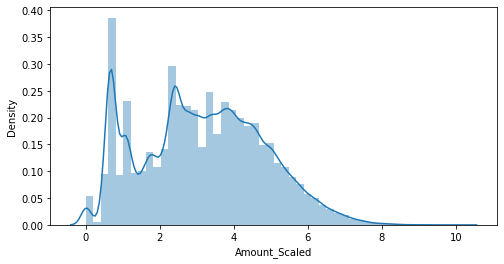

In [40]:
# 로그 변환 후 확인

df = get_preprocessed_df(card_df)
plt.figure(figsize=(8, 4))
sns.distplot(df['Amount_Scaled'])
plt.show()

In [43]:
# 전처리 함수 수정 (log 변환)

def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
    return df_copy

In [35]:
# 다시 성능 확인
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df) 

print('로지스틱 회귀 예측 성능')
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test) 

print('LGBM 예측 성능')
lgbm_clf = LGBMClassifier(n_estimatiors=1000, num_leaves=64, n_jobs=1, boost_from_average=False)    
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test) 

로지스틱 회귀 예측 성능
오차 행렬
[[85283    12]
 [   59    89]]
정확도: 0.9992, 정밀도: 0.8812, 재현율: 0.6014, F1: 0.7149, AUC: 0.9727
LGBM 예측 성능
오차 행렬
[[85289     6]
 [   39   109]]
정확도: 0.9995, 정밀도: 0.9478, 재현율: 0.7365, F1: 0.8289, AUC: 0.9722


### log 변환 전 예측 성능

- 로지스틱 회귀 예측 성능

`오차 행렬
[[85281    14]
 [   56    92]]
정확도: 0.9992, 정밀도: 0.8679, 재현율: 0.6216, F1: 0.7244, AUC: 0.9609`

- LGBM 예측 성능

`오차 행렬
[[85290     5]
 [   38   110]]
정확도: 0.9995, 정밀도: 0.9565, 재현율: 0.7432, F1: 0.8365, AUC: 0.9779`

교재와는 다르게 별차이 없다. 오히려 좀 더 떨어진 느낌

# 이상치 데이터 제거 후 모델 학습/예측/평가

이상치를 찾는 방법 중 IQR을 사용해본다. IQR은 사분위 값의 편차를 이용하는 기법으로 박스 플롯 방식으로 시각화할 수 있다. 

최소값 이하와 최대값 이상의 이상치를 제거한다. 

어떤 피쳐에서 이상치를 제거할지 선택해야 한다. 피쳐가 많을 경우 레이블과 가장 상관성이 높은 피쳐들을 위주로 이상치를 검출하는 것이 좋다. 모든 피쳐들의 이상치를 검출하는 것은 시간이 많이 걸리고 레이블과 상관성이 높지 않다면 이상치를 제거해도 성능에 미치는 영향이 크지 않다.

먼저 피쳐별로 상관도를 구하고 시각화 해본다.

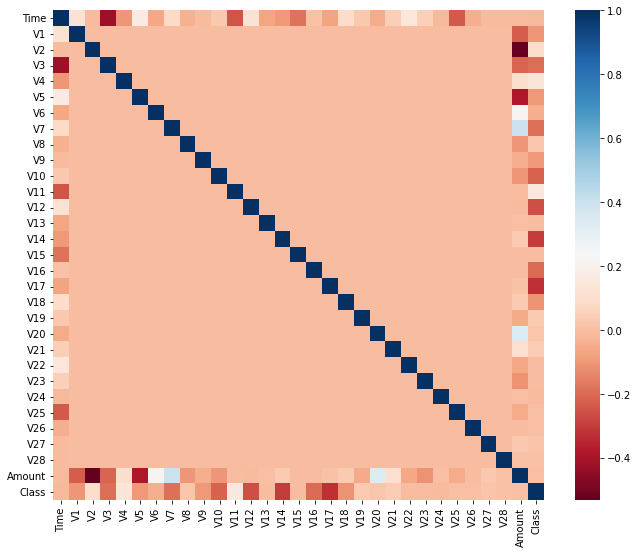

In [47]:
plt.figure(figsize=(11,9))
corr = card_df.corr()
sns.heatmap(corr, cmap='RdBu')
plt.show()

진한 빨강색일 수록 음의 상관관계가 높은 것이다. v14, v17이 레이블과 음의 상관관계가 높다. 

V14만 이상치를 제거해본다. 

In [59]:
# 이상치를 검출하는 함수 작성
def get_outlier(df=None, column=None, weight=1.5):
    fraud = df[df['Class']==1][column] # 레이블이 1인 데이터의 컬럼만 가져온다. 
    quantile_25 = np.percentile(fraud.values, 25)    # 1/4, 3/4 지점을 찾는다. 
    quantile_75 = np.percentile(fraud.values, 75)
    iqr = quantile_75 - quantile_25                 # 범위를 구한다. 
    iqr_weight = iqr * weight                       # 범위에 1.5를 곱해서 최대값과 최소값을 구한다. 
    lowest_val = quantile_25 - iqr_weight
    highest_val = quantile_75 + iqr_weight
    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index  # 최대값과 최소값을 넘어가는 값의 인덱스를 구한다.  
    return outlier_index

In [60]:
outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
outlier_index

Int64Index([8296, 8615, 9035, 9252], dtype='int64')

In [61]:
# 전처리 함수 수정 (log 변환 후 V14피쳐의 이상치를 제거)

def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)

    outlier_index = get_outlier(df_copy, 'V14') # 
    df_copy.drop(outlier_index, axis=0, inplace=True)
    return df_copy

X_train, X_test, y_train, y_test = get_train_test_dataset(card_df) 

print('로지스틱 회귀 예측 성능')
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test) 

print('LGBM 예측 성능')
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)     

로지스틱 회귀 예측 성능
오차 행렬
[[85281    14]
 [   48    98]]
정확도: 0.9993, 정밀도: 0.8750, 재현율: 0.6712, F1: 0.7597, AUC: 0.9743
LGBM 예측 성능
오차 행렬
[[85290     5]
 [   29   117]]
정확도: 0.9996, 정밀도: 0.9590, 재현율: 0.8014, F1: 0.8731, AUC: 0.9701


- 로그 변환 후 예측 성능

로지스틱 회귀 예측 성능

`오차 행렬
[[85283    12]
 [   59    89]]
정확도: 0.9992, 정밀도: 0.8812, 재현율: 0.6014, F1: 0.7149, AUC: 0.9727`

LGBM 예측 성능

`오차 행렬
[[85289     6]
 [   39   109]]
정확도: 0.9995, 정밀도: 0.9478, 재현율: 0.7365, F1: 0.8289, AUC: 0.9722`

두 모델 모두 재현율이 급격하게 상승해서 F1 score가 크게 상승했다!!

# SMOTE 오버 샘플링 적용 후 모델 학습/예측/평가

SMOTE를 적용할 때는 반드시 학습 데이터 셋에만 오버 샘플링을 해야 한다.


In [66]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train) # 메서드 이름 변경되었다. 
print('원본 훈련 셋 :' , X_train.shape, y_train.shape)
print('SMOTE 적용 후 훈련 셋 :', X_train_over.shape, y_train_over.shape)
print('SMOTE 적용 후 레이블 분포 :\n', pd.Series(y_train_over).value_counts())

원본 훈련 셋 : (199362, 29) (199362,)
SMOTE 적용 후 훈련 셋 : (398040, 29) (398040,)
SMOTE 적용 후 레이블 분포 :
 0    199020
1    199020
Name: Class, dtype: int64


데이터가 거의 2배에 가깝게 증식되었다. 

In [67]:
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test) 

오차 행렬
[[82937  2358]
 [   11   135]]
정확도: 0.9723, 정밀도: 0.0542, 재현율: 0.9247, F1: 0.1023, AUC: 0.9737


로지스틱 회귀 모델의 경우 SMOTE로 오버 샘플링된 데이터를 학습하면 재현율이 92%로 크게 오르지만 정밀도는 5.4%로 급격하게 저하된다.

실제 원본 데이터의 유형보다 너무나 많은 Class==1 데이터를 학습하면서 실제 테스트 셋에서 예측을 1로 지나치게 많이 했다.

분류 결정 임계값에 따른 정밀도와 재현율 곡선을 통해서 어떤 문제인지 확인해본다. 

In [68]:
from sklearn.metrics import precision_recall_curve

def precision_recall_curve_plot(y_test, pred_proba_c1):
    # threshold에 따른 정밀도, 재현율 ndarray 추출
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
    
    # X축을 threshold값으로, Y축을 정밀도, 재현율 값으로 
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')

    # threshold 값 x축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))

    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

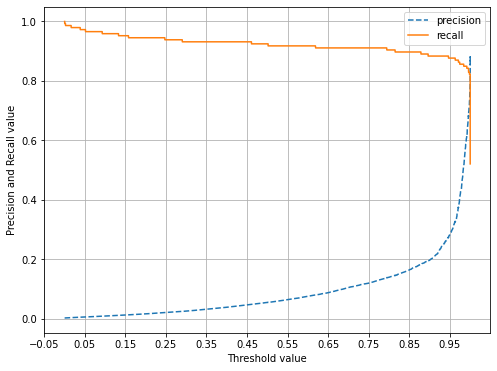

In [69]:
precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])

임계값이 0.99이하에서는 recall이 매우 좋고 precision은 극단적으로 낮다가 0.99이상에서는 반대로 recall은 대폭 떨어지고 precision은 높아진다. 임계값을 조정해도 임계값의 민감도가 너무 심해서 올바른 precision/recall 성능을 얻을 수 없으므로 로지스틱회귀 모델은 SMOTE 적용 후 올바른 예측 모델이 되지 못했다. 

In [71]:
lgbm_clf = LGBMClassifier(n_estimatiors=1000, num_leaves=64, n_jobs=1, boost_from_average=False)    
get_model_train_eval(lgbm_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)     

오차 행렬
[[85257    38]
 [   22   124]]
정확도: 0.9993, 정밀도: 0.7654, 재현율: 0.8493, F1: 0.8052, AUC: 0.9778


SMOTE를 적용하면 재현율은 높아지고 정밀도는 낮아지는 게 일반적이다. 

(정밀도가 책보다 심하게 낮아졌다.)


# 스태킹 앙상블

스태킹은 개별적인 여러 알고리즘을 서로 결합해 예측 결과를 도출한다.

배깅과 부스팅과 가장 큰 차이점은 개별 알고리즘으로 예측한 데이터를 기반으로 다시 예측을 수행한다는 점이다. 즉, 개별 알고리즘의 예측 결과 데이터 셋을 최종적인 메타 데이터 셋으로 만들어 별도의 ML알고리즘으로 최종 학습을 수행하고 테스트 셋을 기반으로 다시 최종 예측을 수행하는 방식이다. 

스태킹 모델은 두 종류의 모델이 필요하다. 첫 번째는 개별적인 기반 모델이고, 두 번째는 이 개별 기반 모델의 예측 데이터를 학습 데이터로 만들어서 학습하는 최종 메타 모델이다. 스태킹 모델의 핵심은 여러 개별 모델의 예측 데이터를 각각 스태킹 형태로 결합해 최종 메타 모델의 학습용 피처 데이터 셋과 테스트용 피처 데이터 셋을 만드는 것이다. 

스태킹을 현실 모델에 적용하는 경우는 그렇게 많지 않다. 

# CV 셋 기반의 스태킹

CV 셋 기반의 스태킹 모델은 과적합을 개선하기 위해 최종 메타 모델을 위한 데이터 셋을 만들 때 교차 검증 기반으로 예측된 결과 데이터 셋을 사용한다. 앞에서 본 메타 모델이 최종 학습을 할 때 y_test로 학습했기 때문에 과적합이 발생할 수 있다. 

이를 개선하기 위해 개별 모델들이 각각 교차 검증으로 메타 모델을 위한 학습용 스태킹 데이터 생성과 예측을 위한 테스트용 스태킹 데이터를 생성 한 뒤 이를 기반으로 메타 모델이 학습과 예측을 수행한다. 

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
    kf = KFold(n_splits=n_folds, shuffle=False, random_state=0)
    train_fold_pred = np.zeros((X_train_n.shape[0], 1))
    test_pred = np.zeros((X_test_n.shape[0], n_folds))
    print(model.__class__.__name__, 'model 시작')

    for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        print('\t 폴드 셋: ', folder_counter, ' 시작')
        X_tr = X_train_n[train_index]
        y_tr = X_train_n[train_index]
        X_te = X_train_n[valid_index]

        model.fit(X_tr, y_tr)
        train_fold_pred[vaild_index, :] = 